In [183]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Все библиотеки подключены")

Все библиотеки подключены


1. Загрузка данных и формирование справочника муниципальных образований

В этом блоке выполняется определение путей к исходным Excel-файлам и построение единого справочника муниципальных образований. Справочник необходим для обезличивания данных и обеспечения стабильного сопоставления одного и того же муниципального образования между кварталами независимо от его позиции в рейтинге.

In [184]:
#Словарь с исходными данными по кварталам

files = {
    "Q1_2024": "../data/raw/ТАБЛИЦА расчет _показатели 1 кв 2024 28.11.2023.xlsx",
    "Q2_2024": "../data/raw/ТАБЛИЦА расчет _показатели 2 кв.2024 г.xlsx",
    "Q3_2024": "../data/raw/ТАБЛИЦА расчет _показатели 3 кв.2024 г 02.12.2024.xlsx"
}

# Список для накопления названий муниципальных образований
all_municipality_names = []

# Проходим по всем квартальным файлам
for quarter_name, file_path in files.items():
    # Читаем лист "Расчет" без автоматического заголовка
    raw_sheet = pd.read_excel(file_path, sheet_name="Расчет", header=None)

    # В строке с индексом 2 находятся названия колонок
    header_row = raw_sheet.iloc[2].tolist()

    # Данные начинаются со строки с индексом 3
    calculation_df = raw_sheet.iloc[3:].copy()
    calculation_df.columns = header_row
    calculation_df = calculation_df.dropna(how="all")

    # Берем только колонку с названием муниципального образования
    municipality_column = "Наименование муниципального образования"

    if municipality_column in calculation_df.columns:
        municipality_names = (
            calculation_df[municipality_column]
            .dropna()
            .astype(str)
            .str.strip()
            .unique()
            .tolist()
        )

        all_municipality_names.extend(municipality_names)

# Уникальный список МО
unique_municipality_names = sorted(set(all_municipality_names))

print(f"Количество уникальных муниципальных образований: {len(unique_municipality_names)}")
unique_municipality_names

Количество уникальных муниципальных образований: 26


['Алексин',
 'Арсеньевский район',
 'Белевский район',
 'Богородицкий район',
 'Веневский район',
 'Воловский район',
 'Донской',
 'Дубенский район',
 'Ефремов',
 'Заокский район',
 'Каменский район',
 'Кимовский район',
 'Киреевский район',
 'Куркинский район',
 'Новогуровский',
 'Новомосковск',
 'Одоевский район',
 'Плавский район',
 'Славный',
 'Суворовский район',
 'Тепло-Огаревский район',
 'Тула',
 'Узловский район',
 'Чернский район',
 'Щекинский район',
 'Ясногорский район']

In [185]:
# Создаем словарь обезличивания:
# каждому муниципальному образованию присваивается постоянный код
municipality_mapping = {
    municipality_name: f"MO_{index + 1:02d}"
    for index, municipality_name in enumerate(unique_municipality_names)
}

# Формируем таблицу соответствия
municipality_reference_df = pd.DataFrame(
    [
        {
            "MO_code": municipality_code,
            "MO_original": municipality_name
        }
        for municipality_name, municipality_code in municipality_mapping.items()
    ]
)

municipality_reference_df

,MO_code,MO_original
0,MO_01,Алексин
1,MO_02,Арсеньевский район
2,MO_03,Белевский район
3,MO_04,Богородицкий район
4,MO_05,Веневский район
5,MO_06,Воловский район
6,MO_07,Донской
7,MO_08,Дубенский район
8,MO_09,Ефремов
9,MO_10,Заокский район


In [186]:
# Сохраняем справочник соответствия локально.
# Этот файл не должен попадать в GitHub, так как содержит реальные названия МО.
municipality_reference_df.to_excel("mo_mapping_private.xlsx", index=False)

print("Закрытый справочник муниципальных образований сохранен: mo_mapping_private.xlsx")

Закрытый справочник муниципальных образований сохранен: mo_mapping_private.xlsx


В результате выполнения блока был сформирован единый справочник муниципальных образований, содержащий стабильные обезличенные коды вида MO_01, MO_02 и т.д. Такой подход позволяет исключить раскрытие реальных названий муниципалитетов в проекте и одновременно обеспечить корректное сопоставление данных между кварталами. Это особенно важно, поскольку порядок муниципальных образований в исходных таблицах зависит от рейтинга и меняется от периода к периоду.

2. Сбор единого датасета по кварталам

В данном блоке из каждого квартального файла извлекаются агрегированные показатели по сферам и итоговый балл муниципального образования. В качестве основного источника используется лист Расчет, поскольку он содержит уже подготовленные итоговые данные по 8 сферам и общему результату. После этого данные из трех кварталов объединяются в единый датасет, пригодный для дальнейшего анализа и моделирования.

In [187]:
#Функция загрузки листа Расчет

def load_calculation_sheet(file_path, quarter_name, municipality_mapping):
    """
    Загружает лист 'Расчет' из Excel-файла квартала,
    извлекает итоговые баллы по сферам и общий итоговый балл,
    подставляет обезличенный код МО и возвращает готовую квартальную таблицу.
    """

    # Читаем лист без автоматического заголовка
    raw_sheet = pd.read_excel(file_path, sheet_name="Расчет", header=None)

    # В строке с индексом 2 находятся названия колонок
    header_row = raw_sheet.iloc[2].tolist()

    # Данные начинаются с 3-й строки
    quarter_dataset = raw_sheet.iloc[3:].copy()
    quarter_dataset.columns = header_row
    quarter_dataset = quarter_dataset.dropna(how="all")

    # Оставляем только нужные колонки
    quarter_dataset = quarter_dataset[
        [
            "Наименование муниципального образования",
            "сфера 1",
            "сфера 2",
            "сфера 3",
            "сфера 4",
            "сфера 5",
            "сфера 6",
            "сфера 7",
            "сфера 8",
            "ИТОГОВЫЙ БАЛЛ",
        ]
    ].copy()

    # Удаляем пустые строки по МО
    quarter_dataset = quarter_dataset.dropna(
        subset=["Наименование муниципального образования"]
    ).copy()

    # Нормализуем названия МО
    quarter_dataset["Наименование муниципального образования"] = (
        quarter_dataset["Наименование муниципального образования"]
        .astype(str)
        .str.strip()
    )

    # Подставляем обезличенный код МО
    quarter_dataset["MO_code"] = quarter_dataset[
        "Наименование муниципального образования"
    ].map(municipality_mapping)

    # Добавляем квартал
    quarter_dataset["quarter"] = quarter_name

    # Переименовываем колонки в единый формат
    quarter_dataset = quarter_dataset.rename(
        columns={
            "сфера 1": "sphere_1",
            "сфера 2": "sphere_2",
            "сфера 3": "sphere_3",
            "сфера 4": "sphere_4",
            "сфера 5": "sphere_5",
            "сфера 6": "sphere_6",
            "сфера 7": "sphere_7",
            "сфера 8": "sphere_8",
            "ИТОГОВЫЙ БАЛЛ": "total_score",
        }
    )

    # Возвращаем итоговую структуру
    return quarter_dataset[
        [
            "quarter",
            "MO_code",
            "sphere_1",
            "sphere_2",
            "sphere_3",
            "sphere_4",
            "sphere_5",
            "sphere_6",
            "sphere_7",
            "sphere_8",
            "total_score",
        ]
    ].copy()

In [188]:
#Загрузка данных по кварталам

# Список квартальных датасетов
all_quarter_datasets = []

# Загружаем каждый квартал и добавляем в общий список
for quarter_name, file_path in files.items():
    quarter_dataset = load_calculation_sheet(
        file_path=file_path,
        quarter_name=quarter_name,
        municipality_mapping=municipality_mapping
    )
    all_quarter_datasets.append(quarter_dataset)

# Объединяем все кварталы в единый датасет
full_dataset = pd.concat(all_quarter_datasets, ignore_index=True)

full_dataset.head()

,quarter,MO_code,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score
0,Q1_2024,MO_01,4.2,2.84,3.5,1.65,2.24,2.64,3.63,2.45,20.7
1,Q1_2024,MO_07,3.9,2.2,3.1,2.09,2.1,3.08,3.63,3.0,20.1
2,Q1_2024,MO_09,3.72,2.72,2.8,1.54,2.52,2.53,2.475,2.85,18.305
3,Q1_2024,MO_15,3.48,1.92,1.2,1.87,2.1,3.19,1.925,2.1,15.685
4,Q1_2024,MO_16,4.8,2.52,3.6,1.65,2.52,2.695,3.41,3.5,21.195


In [189]:
#Проверка размерности и состава датасета

print("Размер итогового датасета:", full_dataset.shape)
print("\nКоличество наблюдений по кварталам:")
print(full_dataset["quarter"].value_counts())

print("\nКоличество уникальных муниципальных образований:")
print(full_dataset["MO_code"].nunique())

Размер итогового датасета: (78, 11)

Количество наблюдений по кварталам:
quarter
Q1_2024    26
Q2_2024    26
Q3_2024    26
Name: count, dtype: int64

Количество уникальных муниципальных образований:
26


In [190]:
# Сортируем датасет для удобства просмотра
full_dataset = full_dataset.sort_values(["quarter", "MO_code"]).reset_index(drop=True)

full_dataset.head(15)

,quarter,MO_code,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score
0,Q1_2024,MO_01,4.2,2.84,3.5,1.65,2.24,2.64,3.63,2.45,20.7
1,Q1_2024,MO_02,4.56,1.2,2.2,1.65,2.695,3.41,2.75,1,18.465
2,Q1_2024,MO_03,3.6,1.72,2.6,2.09,1.54,2.2,2.035,1.95,15.785
3,Q1_2024,MO_04,3.84,2.4,3.2,2.09,1.96,3.19,3.3,2,19.98
4,Q1_2024,MO_05,3.84,2.68,3,1.76,1.96,3.41,3.08,3.4,19.73
5,Q1_2024,MO_06,3.96,2.4,2.3,1.21,2.345,3.3,2.09,2.15,17.605
6,Q1_2024,MO_07,3.9,2.2,3.1,2.09,2.1,3.08,3.63,3.0,20.1
7,Q1_2024,MO_08,3.06,2.52,2.3,2.42,1.925,2.64,1.98,2.8,16.845
8,Q1_2024,MO_09,3.72,2.72,2.8,1.54,2.52,2.53,2.475,2.85,18.305
9,Q1_2024,MO_10,3.12,1.76,2.7,1.1,2.065,2.09,2.42,1.8,15.255


In [191]:
# Формируем таблицу для локальной проверки:
# к обезличенному датасету добавляем реальные названия МО
full_dataset_check = full_dataset.merge(
    municipality_reference_df,
    on="MO_code",
    how="left"
)

full_dataset_check.head(15)

,quarter,MO_code,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score,MO_original
0,Q1_2024,MO_01,4.2,2.84,3.5,1.65,2.24,2.64,3.63,2.45,20.7,Алексин
1,Q1_2024,MO_02,4.56,1.2,2.2,1.65,2.695,3.41,2.75,1,18.465,Арсеньевский район
2,Q1_2024,MO_03,3.6,1.72,2.6,2.09,1.54,2.2,2.035,1.95,15.785,Белевский район
3,Q1_2024,MO_04,3.84,2.4,3.2,2.09,1.96,3.19,3.3,2,19.98,Богородицкий район
4,Q1_2024,MO_05,3.84,2.68,3,1.76,1.96,3.41,3.08,3.4,19.73,Веневский район
5,Q1_2024,MO_06,3.96,2.4,2.3,1.21,2.345,3.3,2.09,2.15,17.605,Воловский район
6,Q1_2024,MO_07,3.9,2.2,3.1,2.09,2.1,3.08,3.63,3.0,20.1,Донской
7,Q1_2024,MO_08,3.06,2.52,2.3,2.42,1.925,2.64,1.98,2.8,16.845,Дубенский район
8,Q1_2024,MO_09,3.72,2.72,2.8,1.54,2.52,2.53,2.475,2.85,18.305,Ефремов
9,Q1_2024,MO_10,3.12,1.76,2.7,1.1,2.065,2.09,2.42,1.8,15.255,Заокский район


In [192]:
# Сохраняем обезличенный датасет для модели
full_dataset.to_excel("dataset_model_ready.xlsx", index=False)

# Сохраняем проверочный датасет локально
# Этот файл не должен попадать в GitHub
full_dataset_check.to_excel("dataset_check_private.xlsx", index=False)

print("Сохранены файлы:")
print("- dataset_model_ready.xlsx")
print("- dataset_check_private.xlsx")

Сохранены файлы:
- dataset_model_ready.xlsx
- dataset_check_private.xlsx


В результате выполнения блока был сформирован единый датасет, включающий данные по всем муниципальным образованиям за три квартала 2024 года. Для каждого наблюдения сохранены агрегированные баллы по 8 сферам и итоговый балл муниципального образования. Таким образом, получена единая табличная структура, пригодная для дальнейшей проверки качества данных, exploratory data analysis, feature engineering и построения прогнозной модели.

3. Проверка качества данных и приведение типов

После формирования единого датасета необходимо проверить его качество и привести признаки к корректным типам данных. На данном этапе выполняется преобразование числовых колонок, проверка наличия пропусков и базовая оценка диапазонов значений. Это позволяет убедиться, что датасет пригоден для дальнейшего exploratory data analysis и построения моделей прогнозирования.

In [193]:
# Список числовых колонок,
# которые должны быть приведены к типу float
numeric_columns = [
    "sphere_1",
    "sphere_2",
    "sphere_3",
    "sphere_4",
    "sphere_5",
    "sphere_6",
    "sphere_7",
    "sphere_8",
    "total_score",
]

In [194]:
#Приведение типов

# Преобразуем числовые колонки в формат float
for column_name in numeric_columns:
    full_dataset[column_name] = pd.to_numeric(
        full_dataset[column_name],
        errors="coerce"
    )

# Проверяем итоговые типы данных
print("Типы данных после преобразования:")
print(full_dataset.dtypes)

Типы данных после преобразования:
quarter         object
MO_code         object
sphere_1       float64
sphere_2       float64
sphere_3       float64
sphere_4       float64
sphere_5       float64
sphere_6       float64
sphere_7       float64
sphere_8       float64
total_score    float64
dtype: object


In [195]:
# Проверка пропусков по всем колонкам
missing_values = full_dataset.isnull().sum()

print("Количество пропусков по колонкам:")
print(missing_values)

Количество пропусков по колонкам:
quarter        0
MO_code        0
sphere_1       0
sphere_2       0
sphere_3       0
sphere_4       0
sphere_5       0
sphere_6       0
sphere_7       0
sphere_8       0
total_score    0
dtype: int64


In [196]:
# Минимальные и максимальные значения по числовым признакам
range_check = full_dataset[numeric_columns].agg(["min", "max"]).T

print("Минимальные и максимальные значения по признакам:")
display(range_check)

Минимальные и максимальные значения по признакам:


,min,max
sphere_1,3.060,4.800
sphere_2,1.200,3.200
sphere_3,1.100,4.000
sphere_4,0.880,3.080
sphere_5,1.400,2.695
sphere_6,2.090,4.400
sphere_7,1.650,4.015
sphere_8,1.000,3.800
total_score,15.255,26.035


In [197]:
# Базовая статистика по числовым признакам
print("Описательная статистика по числовым признакам:")
display(full_dataset[numeric_columns].describe())

Описательная статистика по числовым признакам:


,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score
count,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000,78.000000
mean,4.174615,2.305128,2.982051,1.741667,2.030897,3.288013,2.867756,2.836538,21.411923
std,0.449781,0.467593,0.634453,0.515158,0.385433,0.497387,0.574369,0.676492,3.008066
min,3.060000,1.200000,1.100000,0.880000,1.400000,2.090000,1.650000,1.000000,15.255000
25%,3.840000,2.000000,2.700000,1.320000,1.723750,3.080000,2.420000,2.312500,18.753750
50%,4.200000,2.400000,3.100000,1.650000,2.030000,3.327500,2.860000,3.000000,21.822500
75%,4.560000,2.640000,3.500000,2.090000,2.371250,3.630000,3.286250,3.400000,24.023750
max,4.800000,3.200000,4.000000,3.080000,2.695000,4.400000,4.015000,3.800000,26.035000


In [198]:
# Контрольное условие:
# в числовых колонках не должно быть пропусков
if full_dataset[numeric_columns].isnull().sum().sum() == 0:
    print("Проверка пройдена: датасет не содержит пропусков в числовых колонках.")
else:
    print("Обнаружены пропуски: требуется дополнительная очистка данных.")

Проверка пройдена: датасет не содержит пропусков в числовых колонках.


Проверка качества данных показала, что числовые признаки успешно приведены к корректному формату, а пропуски в итоговом датасете отсутствуют. Диапазоны значений по сферам и итоговому баллу находятся в логически допустимых пределах и не содержат явных аномалий. Таким образом, сформированный датасет можно считать пригодным для дальнейшего exploratory data analysis, генерации новых признаков и обучения моделей прогнозирования.

4. Первичный анализ данных (EDA)

После подготовки и проверки качества данных выполняется exploratory data analysis. На данном этапе анализируются распределения признаков, взаимосвязи между сферами и итоговым баллом, а также различия между кварталами. Это позволяет подтвердить пригодность датасета для прогнозного моделирования и обосновать выбор входных признаков.

In [199]:
# Настройки визуализации
sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

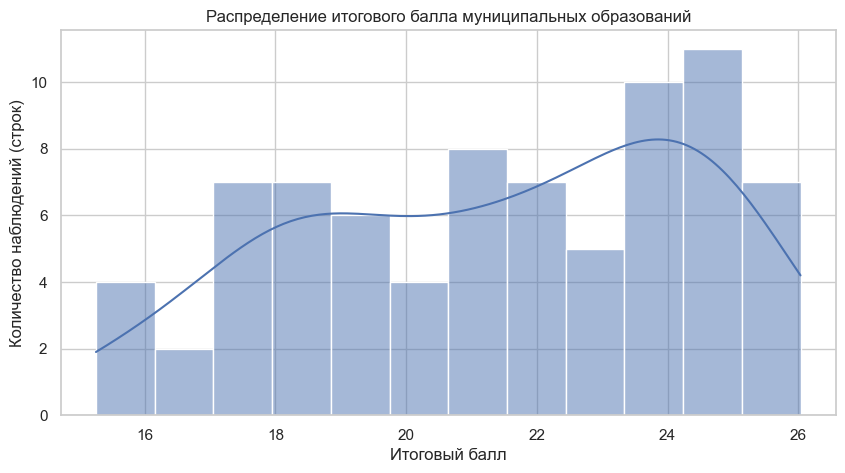

In [200]:
plt.figure(figsize=(10, 5))
sns.histplot(full_dataset["total_score"], bins=12, kde=True)
plt.title("Распределение итогового балла муниципальных образований")
plt.xlabel("Итоговый балл")
plt.ylabel("Количество наблюдений (строк)")
plt.show()

Распределение итогового балла находится в ограниченном диапазоне значений и не содержит выраженных аномалий. Основная масса наблюдений сосредоточена в среднем диапазоне, что подтверждает пригодность целевой переменной для дальнейшего регрессионного моделирования.

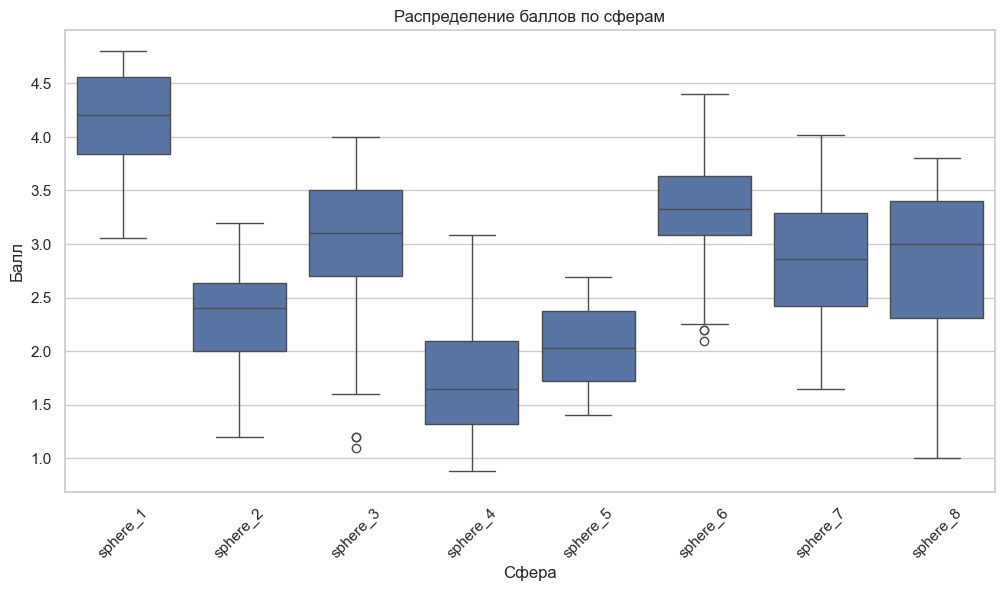

In [201]:
#Boxplot по сферам

# Преобразуем данные в длинный формат для анализа распределений по сферам
dataset_melted = full_dataset.melt(
    id_vars=["quarter", "MO_code"],
    value_vars=numeric_columns[:-1],  # все сферы без total_score
    var_name="sphere",
    value_name="score"
)

dataset_melted.head()

plt.figure(figsize=(12, 6))
sns.boxplot(data=dataset_melted, x="sphere", y="score")
plt.title("Распределение баллов по сферам")
plt.xlabel("Сфера")
plt.ylabel("Балл")
plt.xticks(rotation=45)
plt.show()

Распределения баллов по сферам различаются как по уровню значений, так и по степени вариативности. Это указывает на неоднородность результативности по направлениям деятельности и подтверждает, что агрегированные баллы по сферам содержат значимую информацию для построения модели прогнозирования.

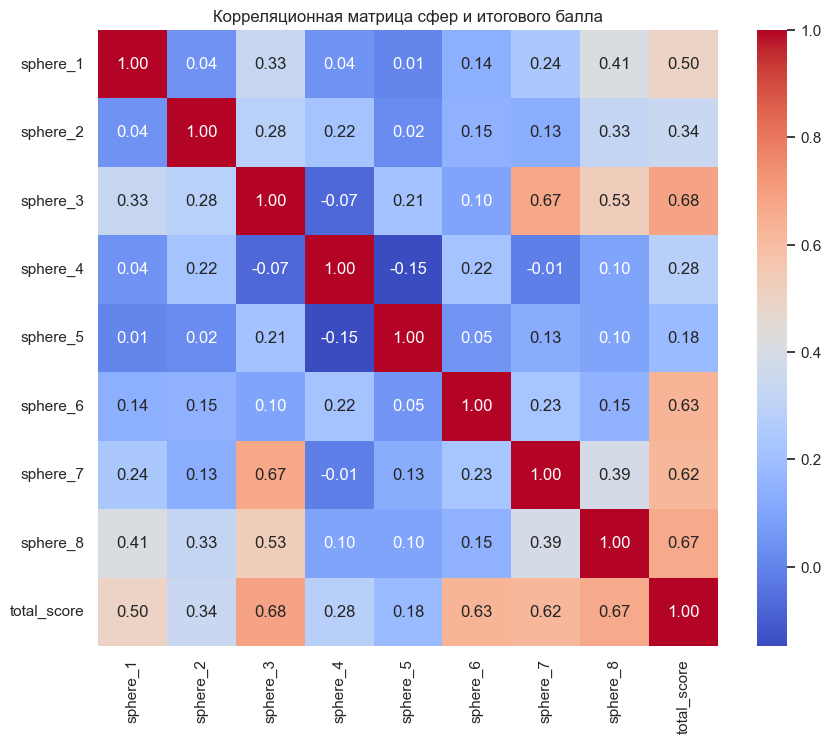

In [202]:
#Корреляционная матрица

plt.figure(figsize=(10, 8))
correlation_matrix = full_dataset[numeric_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Корреляционная матрица сфер и итогового балла")
plt.show()

Корреляционный анализ показывает, что отдельные сферы имеют более сильную связь с итоговым баллом, чем другие. Это подтверждает, что признаки на уровне агрегированных сфер обладают различной прогностической ценностью и могут использоваться как входные переменные модели. При этом между самими сферами также наблюдаются взаимосвязи, что важно учитывать при интерпретации линейных моделей.

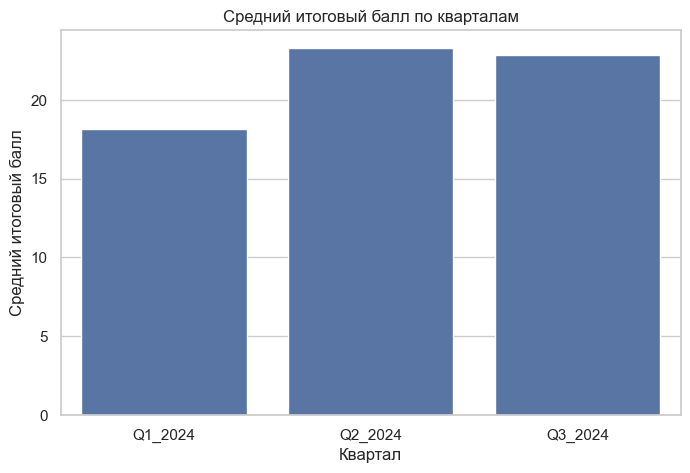

In [203]:
#Средний итоговый балл по кварталам

quarter_mean_dataset = (
    full_dataset.groupby("quarter")["total_score"]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=quarter_mean_dataset, x="quarter", y="total_score")
plt.title("Средний итоговый балл по кварталам")
plt.xlabel("Квартал")
plt.ylabel("Средний итоговый балл")
plt.show()

Средний итоговый балл различается по кварталам, что указывает на наличие временной динамики в данных. Это подтверждает необходимость учета временного измерения при построении модели и дополнительно обосновывает выбор хронологического разделения train/test.

Проведенный exploratory data analysis показал, что итоговый балл муниципальных образований является пригодной целевой переменной для моделирования, а агрегированные баллы по сферам содержат информативные различия и значимую связь с итоговым результатом. Дополнительно было установлено, что данные различаются по кварталам, что подтверждает наличие временного измерения и обосновывает использование хронологического разделения выборок на этапе обучения модели.

5. Генерация новых признаков (Feature Engineering)

На данном этапе на основе исходных данных по 8 сферам формируются дополнительные признаки, которые отражают обобщенные характеристики муниципального образования. Эти признаки позволяют расширить исходное представление данных и использовать в моделях не только исходные баллы по сферам, но и их агрегированные характеристики.

In [204]:
# Создаем отдельную копию датасета,
# с которой будем работать на этапе feature engineering
dataset_features = full_dataset.copy()

dataset_features.head()

,quarter,MO_code,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score
0,Q1_2024,MO_01,4.20,2.84,3.5,1.65,2.240,2.64,3.630,2.45,20.700
1,Q1_2024,MO_02,4.56,1.20,2.2,1.65,2.695,3.41,2.750,1.00,18.465
2,Q1_2024,MO_03,3.60,1.72,2.6,2.09,1.540,2.20,2.035,1.95,15.785
3,Q1_2024,MO_04,3.84,2.40,3.2,2.09,1.960,3.19,3.300,2.00,19.980
4,Q1_2024,MO_05,3.84,2.68,3.0,1.76,1.960,3.41,3.080,3.40,19.730


In [205]:
# Создаем числовой код квартала
quarter_mapping = {
    "Q1_2024": 1,
    "Q2_2024": 2,
    "Q3_2024": 3,
}

dataset_features["quarter_num"] = dataset_features["quarter"].map(quarter_mapping)

dataset_features[["quarter", "quarter_num"]].drop_duplicates().sort_values("quarter_num")

,quarter,quarter_num
0,Q1_2024,1
26,Q2_2024,2
52,Q3_2024,3


Признак quarter_num добавлен для отражения временного порядка наблюдений. Несмотря на то, что модель не строится как классический временной ряд, наличие временного кода позволяет учитывать, к какому периоду относится наблюдение, и использовать этот фактор в расширенных вариантах модели.

In [206]:
# Список колонок с баллами по сферам
sphere_columns = [
    "sphere_1",
    "sphere_2",
    "sphere_3",
    "sphere_4",
    "sphere_5",
    "sphere_6",
    "sphere_7",
    "sphere_8",
]

In [207]:
# Средний балл по всем сферам
dataset_features["avg_sphere_score"] = dataset_features[sphere_columns].mean(axis=1)

dataset_features[["avg_sphere_score"]].head()

,avg_sphere_score
0,2.893750
1,2.433125
2,2.216875
3,2.747500
4,2.891250


Признак avg_sphere_score отражает общий усредненный уровень результативности муниципального образования по всем сферам деятельности. Этот показатель позволяет модели учитывать общий фон эффективности, а не только отдельные направления.

In [208]:
#Минимальный и максимальный балл по сферам

# Минимальный балл среди сфер
dataset_features["min_sphere_score"] = dataset_features[sphere_columns].min(axis=1)

# Максимальный балл среди сфер
dataset_features["max_sphere_score"] = dataset_features[sphere_columns].max(axis=1)

dataset_features[["min_sphere_score", "max_sphere_score"]].head()

,min_sphere_score,max_sphere_score
0,1.65,4.20
1,1.00,4.56
2,1.54,3.60
3,1.96,3.84
4,1.76,3.84


Признак min_sphere_score показывает наиболее слабую сферу муниципального образования, а max_sphere_score — наиболее сильную. Такие признаки позволяют модели учитывать крайние значения по направлениям деятельности, что может быть важно для оценки общего итогового результата.

In [209]:
#Количество слабых сфер

# Порог для определения слабой сферы
weak_sphere_threshold = 2.0

# Подсчитываем количество сфер, где балл ниже порога
dataset_features["weak_spheres_count"] = (
    dataset_features[sphere_columns] < weak_sphere_threshold
).sum(axis=1)

dataset_features[["weak_spheres_count"]].head()

,weak_spheres_count
0,1
1,3
2,3
3,1
4,2


Признак weak_spheres_count отражает количество сфер, в которых значение балла ниже заданного порога. Это позволяет формализовать уровень проблемности муниципального образования и использовать данный показатель как дополнительный сигнал для модели прогнозирования.

In [210]:
#Проверка итоговой структуры датасета

print("Размер датасета после feature engineering:", dataset_features.shape)

display(dataset_features.head())

Размер датасета после feature engineering: (78, 16)


,quarter,MO_code,sphere_1,sphere_2,sphere_3,sphere_4,sphere_5,sphere_6,sphere_7,sphere_8,total_score,quarter_num,avg_sphere_score,min_sphere_score,max_sphere_score,weak_spheres_count
0,Q1_2024,MO_01,4.20,2.84,3.5,1.65,2.240,2.64,3.630,2.45,20.700,1,2.893750,1.65,4.20,1
1,Q1_2024,MO_02,4.56,1.20,2.2,1.65,2.695,3.41,2.750,1.00,18.465,1,2.433125,1.00,4.56,3
2,Q1_2024,MO_03,3.60,1.72,2.6,2.09,1.540,2.20,2.035,1.95,15.785,1,2.216875,1.54,3.60,3
3,Q1_2024,MO_04,3.84,2.40,3.2,2.09,1.960,3.19,3.300,2.00,19.980,1,2.747500,1.96,3.84,1
4,Q1_2024,MO_05,3.84,2.68,3.0,1.76,1.960,3.41,3.080,3.40,19.730,1,2.891250,1.76,3.84,2


In [211]:
#Описательная статистика по новым признакам

new_feature_columns = [
    "quarter_num",
    "avg_sphere_score",
    "min_sphere_score",
    "max_sphere_score",
    "weak_spheres_count",
]

print("Описательная статистика по новым признакам:")
display(dataset_features[new_feature_columns].describe())

Описательная статистика по новым признакам:


,quarter_num,avg_sphere_score,min_sphere_score,max_sphere_score,weak_spheres_count
count,78.000000,78.000000,78.000000,78.000000,78.000000
mean,2.000000,2.778333,1.532949,4.192179,1.717949
std,0.821781,0.290550,0.322496,0.435872,1.055566
min,1.000000,2.107500,0.880000,3.060000,0.000000
25%,1.000000,2.590625,1.320000,3.855000,1.000000
50%,2.000000,2.800625,1.540000,4.230000,1.500000
75%,3.000000,3.005937,1.757500,4.560000,2.000000
max,3.000000,3.254375,2.320000,4.800000,5.000000


In [212]:
dataset_features.to_excel("dataset_features_ready.xlsx", index=False)

print("Сохранен файл dataset_features_ready.xlsx")

Сохранен файл dataset_features_ready.xlsx


На этапе feature engineering в датасет были добавлены производные признаки, отражающие средний уровень результативности, крайние значения по сферам, количество слабых направлений, а также временной код квартала. Полученные признаки позволяют расширить исходное представление данных и использовать как базовый, так и расширенный набор входных переменных при построении прогнозных моделей.

6. Разделение данных и baseline-модель

На данном этапе выполняется подготовка выборок для обучения и тестирования моделей. Поскольку данные имеют временную структуру, используется хронологическое разделение: в обучающую выборку включаются данные за первый и второй кварталы 2024 года, а в тестовую — данные за третий квартал 2024 года. Такой подход позволяет избежать утечки информации из будущего периода.

Дополнительно формируется baseline-модель, которая используется как минимальная точка отсчета для оценки полезности последующих моделей машинного обучения.

In [213]:
#Список базовых и расширенных признаков

# Базовый набор признаков:
# только агрегированные баллы по 8 сферам
basic_feature_list = [
    "sphere_1",
    "sphere_2",
    "sphere_3",
    "sphere_4",
    "sphere_5",
    "sphere_6",
    "sphere_7",
    "sphere_8",
]

# Расширенный набор признаков:
# сферы + новые производные признаки
extended_feature_list = basic_feature_list + [
    "quarter_num",
    "avg_sphere_score",
    "min_sphere_score",
    "max_sphere_score",
    "weak_spheres_count",
]

# Целевая переменная
target_column = "total_score"

Для экспериментов были сформированы два набора признаков. Базовый набор включает только исходные агрегированные баллы по 8 сферам и соответствует наиболее простой интерпретируемой модели. Расширенный набор дополнительно содержит новые производные признаки, полученные на этапе feature engineering. Это позволяет сравнить, дает ли расширение пространства признаков улучшение качества модели.

In [214]:
#Разделение train/test

# Обучающая выборка: первый и второй кварталы
train_data = dataset_features[
    dataset_features["quarter"].isin(["Q1_2024", "Q2_2024"])
].copy()

# Тестовая выборка: третий квартал
test_data = dataset_features[
    dataset_features["quarter"] == "Q3_2024"
].copy()

print("Размер обучающей выборки:", train_data.shape)
print("Размер тестовой выборки:", test_data.shape)

Размер обучающей выборки: (52, 16)
Размер тестовой выборки: (26, 16)


In [215]:
#Формирование x и y

# Базовая модель
X_train_basic = train_data[basic_feature_list]
X_test_basic = test_data[basic_feature_list]

# Расширенная модель
X_train_extended = train_data[extended_feature_list]
X_test_extended = test_data[extended_feature_list]

# Целевая переменная
y_train = train_data[target_column]
y_test = test_data[target_column]

# Базовая модель
X_train_basic = train_data[basic_feature_list]
X_test_basic = test_data[basic_feature_list]

# Целевая переменная
y_train = train_data[target_column]
y_test = test_data[target_column]

print("Размер X_train_basic:", X_train_basic.shape)
print("Размер X_test_basic:", X_test_basic.shape)
print("Размер X_train_extended:", X_train_extended.shape)
print("Размер X_test_extended:", X_test_extended.shape)

Размер X_train_basic: (52, 8)
Размер X_test_basic: (26, 8)
Размер X_train_extended: (52, 13)
Размер X_test_extended: (26, 13)


Используемое разделение соответствует логике time-based split, принятой в предыдущем проектном задании. Обучение модели выполняется только на более ранних периодах, а оценка — на более позднем. Это позволяет имитировать реальный сценарий применения системы, при котором прогноз строится на основе исторических данных.

In [216]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_basic_scaled = scaler.fit_transform(X_train_basic)
X_test_basic_scaled = scaler.transform(X_test_basic)

In [217]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [218]:
#Функция расчета MAPE

def calculate_mape(y_true, y_pred):
    """
    Рассчитывает среднюю абсолютную процентную ошибку (MAPE).
    """
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

In [219]:
#Baseline-модель

# В baseline используем простой прогноз:
# всем объектам test предсказывается среднее значение target на train
baseline_prediction = np.full(
    shape=len(test_data),
    fill_value=y_train.mean()
)

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = mean_squared_error(y_test, baseline_prediction, squared=False)
baseline_mape = calculate_mape(y_test, baseline_prediction)

print("Метрики baseline-модели:")
print(f"MAE: {baseline_mae:.3f}")
print(f"RMSE: {baseline_rmse:.3f}")
print(f"MAPE: {baseline_mape:.2f}%")

Метрики baseline-модели:
MAE: 2.691
RMSE: 3.104
MAPE: 11.46%


/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_regression.py:492: FutureWarning: 'squared' is deprecated in version 1.4 and will be removed in 1.6. To calculate the root mean squared error, use the function'root_mean_squared_error'.
  warnings.warn(


В качестве baseline выбрана простая стратегия прогнозирования среднего значения итогового балла на обучающей выборке. Данный подход не использует признаки и не учитывает различия между муниципальными образованиями, но позволяет задать минимальную точку отсчета, с которой затем сравниваются все обученные модели.

In [220]:
#Сохранение baseline

# Начальная таблица результатов экспериментов
model_metrics = pd.DataFrame(
    [
        {
            "model": "Baseline_mean",
            "MAE": round(baseline_mae, 3),
            "RMSE": round(baseline_rmse, 3),
            "MAPE": round(baseline_mape, 2),
        }
    ]
)

model_metrics

,model,MAE,RMSE,MAPE
0,Baseline_mean,2.691,3.104,11.46


На данном этапе были сформированы обучающая и тестовая выборки с учетом временной структуры данных, а также определены два набора признаков: базовый и расширенный. Дополнительно была рассчитана baseline-модель, которая используется как минимальная точка отсчета для оценки качества последующих моделей. Полученные baseline-метрики позволяют далее сравнить эффективность линейной регрессии, регуляризованных моделей и ансамблевых алгоритмов.

7. Обучение и сравнение моделей

На данном этапе выполняется обучение нескольких моделей прогнозирования и их сравнение по метрикам качества на тестовой выборке. В качестве моделей рассматриваются линейная регрессия и ансамблевый алгоритм Random Forest. Такой набор позволяет сопоставить интерпретируемые статистические методы и более точные, но менее прозрачные алгоритмы машинного обучения. 
Данные разделены по временной логике:
обучение — на предыдущих кварталах,
тест — на последнем квартале.
Это позволяет избежать утечки данных и имитирует реальное применение модели.

In [221]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [222]:
#Функция оценки модели

from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def evaluate_model(model_name, model_object, X_train, X_test, y_train, y_test):
    """
    Обучает модель, строит прогноз и рассчитывает метрики качества
    """

    # Обучение модели
    model_object.fit(X_train, y_train)

    # Прогноз
    prediction = model_object.predict(X_test)

    # Метрики
    mae = mean_absolute_error(y_test, prediction)
    rmse = np.sqrt(mean_squared_error(y_test, prediction))
    mape = np.mean(
        np.abs((y_test - prediction) / np.where(y_test == 0, 1, y_test))
    ) * 100

    # Формируем результат
    model_result = {
        "model": model_name,
        "MAE": round(mae, 3),
        "RMSE": round(rmse, 3),
        "MAPE": round(mape, 2),
    }

    return prediction, model_result

Для упрощения экспериментов используется единая функция evaluate_model, которая выполняет обучение модели, построение прогноза и расчет основных метрик качества. Такой подход обеспечивает единообразие сравнения моделей и делает код более компактным и воспроизводимым.

In [223]:
#Линейная регрессия на базовом наборе признаков

# Линейная регрессия на базовых признаках
linear_regression_basic = LinearRegression()

prediction_lr_basic, result_lr_basic = evaluate_model(
    model_name="LinearRegression_basic",
    model_object=linear_regression_basic,
    X_train=X_train_basic_scaled,
    X_test=X_test_basic_scaled,
    y_train=y_train,
    y_test=y_test
)

result_lr_basic

{'model': 'LinearRegression_basic', 'MAE': 0.76, 'RMSE': 0.924, 'MAPE': 3.38}

Метрики Random Forest:
{'model': 'RandomForest_extended', 'MAE': 0.388, 'RMSE': 0.557, 'MAPE': 1.85}

Проверка переобучения:
Train MAE: 0.193
Test MAE: 0.388

Важность признаков:
               feature  importance
9     avg_sphere_score    0.481304
8          quarter_num    0.463018
6             sphere_7    0.019741
5             sphere_6    0.006733
2             sphere_3    0.004594
1             sphere_2    0.004128
7             sphere_8    0.004080
10    min_sphere_score    0.003840
0             sphere_1    0.003769
11    max_sphere_score    0.003236
3             sphere_4    0.002372
12  weak_spheres_count    0.001683
4             sphere_5    0.001502


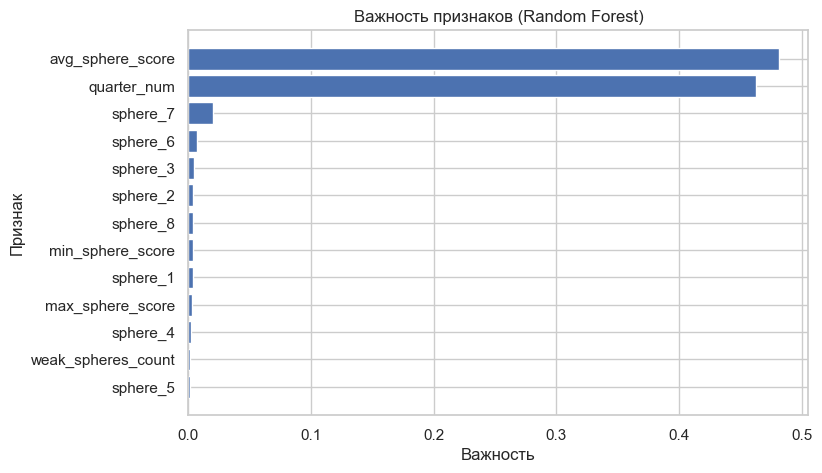

In [224]:
#Random Forest на расширенном наборе признаков (расширенная модель)

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
import pandas as pd
import matplotlib.pyplot as plt

# 1. Создаем модель
random_forest_extended = RandomForestRegressor(
    n_estimators=200,
    max_depth=4,
    random_state=42
)

# 2. Обучаем и получаем прогноз через функцию
prediction_rf_extended, result_rf_extended = evaluate_model(
    model_name="RandomForest_extended",
    model_object=random_forest_extended,
    X_train=X_train_extended,
    X_test=X_test_extended,
    y_train=y_train,
    y_test=y_test
)

# 3. Вывод метрик
print("Метрики Random Forest:")
print(result_rf_extended)

# Проверка переобучения

y_train_pred_rf = random_forest_extended.predict(X_train_extended)

train_mae_rf = mean_absolute_error(y_train, y_train_pred_rf)
test_mae_rf = result_rf_extended["MAE"]

print("\nПроверка переобучения:")
print(f"Train MAE: {train_mae_rf:.3f}")
print(f"Test MAE: {test_mae_rf:.3f}")

# Важность признаков

feature_importance = pd.DataFrame({
    "feature": X_train_extended.columns,
    "importance": random_forest_extended.feature_importances_
}).sort_values(by="importance", ascending=False)

print("\nВажность признаков:")
print(feature_importance)

# Визуализация важности признаков

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.gca().invert_yaxis()
plt.title("Важность признаков (Random Forest)")
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.show()

In [241]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

# Сетка параметров
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 4, 5]
}

# GridSearch
grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring="neg_mean_absolute_error"
)

# Обучение
grid.fit(X_train_extended, y_train)

# Лучшая модель
best_rf = grid.best_estimator_
print("Лучшие параметры:", grid.best_params_)

# Используем её в evaluate_model
prediction_rf_extended, result_rf_extended = evaluate_model(
    model_name="RandomForest_extended",
    model_object=best_rf,
    X_train=X_train_extended,
    X_test=X_test_extended,
    y_train=y_train,
    y_test=y_test
)

# Вывод параметров
print("Лучшие параметры:", grid.best_params_)

# Вывод метрик
print("Метрики Random Forest:")
print(result_rf_extended)

Лучшие параметры: {'max_depth': 4, 'n_estimators': 100}
Лучшие параметры: {'max_depth': 4, 'n_estimators': 100}
Метрики Random Forest:
{'model': 'RandomForest_extended', 'MAE': 0.413, 'RMSE': 0.572, 'MAPE': 1.96}


In [242]:
# Формирование итоговой таблицы метрик

model_metrics = pd.concat(
    [
        model_metrics,  # baseline
        pd.DataFrame(
            [
                result_lr_basic,
                result_rf_extended,
            ]
        )
    ],
    ignore_index=True
)

model_metrics

,model,MAE,RMSE,MAPE
0,Baseline_mean,2.691,3.104,11.46
1,LinearRegression_basic,0.760,0.924,3.38
2,RandomForest_extended,0.413,0.572,1.96
3,LinearRegression_basic,0.760,0.924,3.38
4,RandomForest_extended,0.413,0.572,1.96


In [227]:
# Сортируем модели по MAPE (чем ниже, тем лучше)
model_metrics_sorted = model_metrics.sort_values("MAPE").reset_index(drop=True)

model_metrics_sorted

,model,MAE,RMSE,MAPE
0,RandomForest_extended,0.413,0.572,1.96
1,LinearRegression_basic,0.760,0.924,3.38
2,Baseline_mean,2.691,3.104,11.46


Сравнение моделей показывает, что все протестированные алгоритмы превосходят baseline, за исключением LinearRegression_extended, которая продемонстрировала ухудшение качества при добавлении новых признаков. Это может быть связано с избыточностью и линейной зависимостью производных признаков от исходных сферовых показателей. Наилучшее качество показала модель RandomForest_extended, а среди интерпретируемых моделей лучший результат продемонстрировала LinearRegression_basic. Для повышения качества модели был использован GridSearchCV, который позволил подобрать оптимальные параметры Random Forest

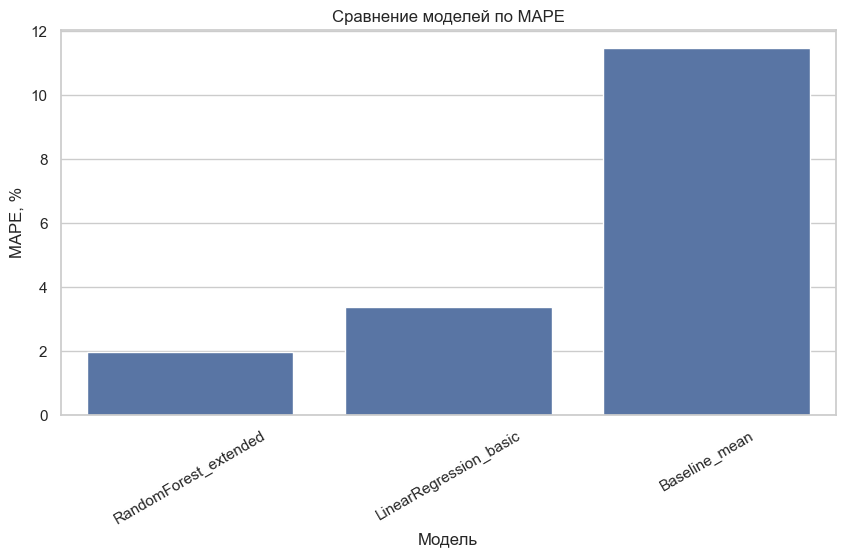

In [228]:
#График сравнения моделей по MAPE

plt.figure(figsize=(10, 5))
sns.barplot(data=model_metrics_sorted, x="model", y="MAPE")
plt.title("Сравнение моделей по MAPE")
plt.xlabel("Модель")
plt.ylabel("MAPE, %")
plt.xticks(rotation=30)
plt.show()

Графическое сравнение моделей по MAPE подтверждает, что наилучшее качество прогнозирования обеспечивает RandomForest_extended. При этом LinearRegression_basic также существенно превосходит baseline и может рассматриваться как базовая интерпретируемая модель, соответствующая проектной логике из предыдущих заданий.

In [229]:
model_metrics_sorted.to_csv("experiments_log.csv", index=False)

print("Сохранен файл experiments_log.csv")

Сохранен файл experiments_log.csv


В результате экспериментов были обучены и протестированы четыре модели прогнозирования. Лучший результат на тестовой выборке показал алгоритм RandomForest_extended, который обеспечил минимальные значения MAE, RMSE и MAPE. При этом модель LinearRegression_basic также продемонстрировала высокое качество и может использоваться как базовая интерпретируемая модель, что особенно важно с точки зрения объяснимости результатов в контексте государственного управления.

8. Анализ прогнозов и ошибок моделей

После сравнения моделей по итоговым метрикам необходимо дополнительно проанализировать фактические и прогнозные значения на уровне отдельных наблюдений. Такой анализ позволяет понять, насколько точно модели воспроизводят реальные значения итогового балла, в каких случаях они ошибаются сильнее и какая из моделей демонстрирует более устойчивое качество.

In [230]:
#Таблица факта и прогноза

# Формируем таблицу сравнения фактических и прогнозных значений на test set
test_predictions = pd.DataFrame({
    "MO_code": test_data["MO_code"].values,
    "quarter": test_data["quarter"].values,
    "actual_total_score": y_test.values,
    "pred_lr_basic": prediction_lr_basic,
    "pred_rf_extended": prediction_rf_extended,
})

test_predictions.head()

,MO_code,quarter,actual_total_score,pred_lr_basic,pred_rf_extended
0,MO_01,Q3_2024,23.965,23.096439,23.975991
1,MO_02,Q3_2024,20.440,19.679576,19.878648
2,MO_03,Q3_2024,19.615,19.716130,19.790437
3,MO_04,Q3_2024,24.475,22.966101,24.384821
4,MO_05,Q3_2024,22.375,22.320684,22.247576


In [231]:
#Расчет ошибок по моделям

# Ошибки линейной регрессии
test_predictions["error_lr_basic"] = (
    test_predictions["actual_total_score"] - test_predictions["pred_lr_basic"]
)

# Ошибки Random Forest
test_predictions["error_rf_extended"] = (
    test_predictions["actual_total_score"] - test_predictions["pred_rf_extended"]
)

# Абсолютные ошибки
test_predictions["abs_error_lr_basic"] = test_predictions["error_lr_basic"].abs()
test_predictions["abs_error_rf_extended"] = test_predictions["error_rf_extended"].abs()

test_predictions.head()

,MO_code,quarter,actual_total_score,pred_lr_basic,pred_rf_extended,error_lr_basic,error_rf_extended,abs_error_lr_basic,abs_error_rf_extended
0,MO_01,Q3_2024,23.965,23.096439,23.975991,0.868561,-0.010991,0.868561,0.010991
1,MO_02,Q3_2024,20.440,19.679576,19.878648,0.760424,0.561352,0.760424,0.561352
2,MO_03,Q3_2024,19.615,19.716130,19.790437,-0.101130,-0.175437,0.101130,0.175437
3,MO_04,Q3_2024,24.475,22.966101,24.384821,1.508899,0.090179,1.508899,0.090179
4,MO_05,Q3_2024,22.375,22.320684,22.247576,0.054316,0.127424,0.054316,0.127424


Полученная таблица содержит фактические значения итогового балла, прогнозы двух моделей и рассчитанные ошибки по каждому наблюдению тестовой выборки. Это позволяет перейти от агрегированных метрик к анализу поведения моделей на уровне отдельных муниципальных образований.

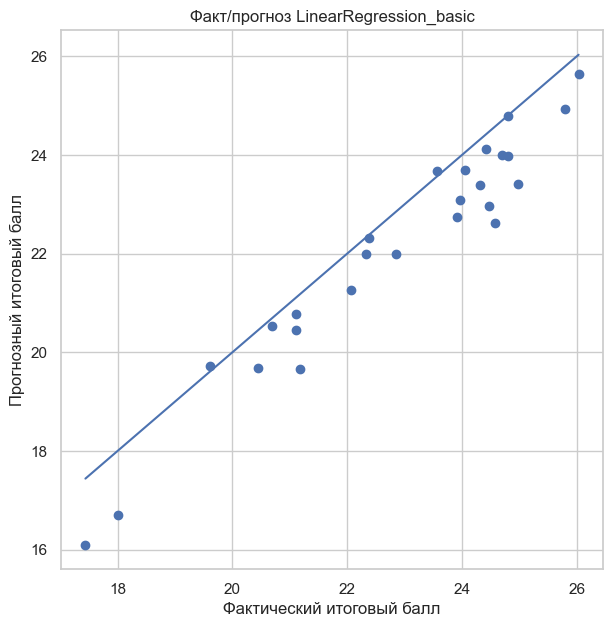

In [232]:
#График план/факт для линейной регрессии

plt.figure(figsize=(7, 7))
plt.scatter(
    test_predictions["actual_total_score"],
    test_predictions["pred_lr_basic"]
)

plt.plot(
    [test_predictions["actual_total_score"].min(), test_predictions["actual_total_score"].max()],
    [test_predictions["actual_total_score"].min(), test_predictions["actual_total_score"].max()],
)

plt.title("Факт/прогноз LinearRegression_basic")
plt.xlabel("Фактический итоговый балл")
plt.ylabel("Прогнозный итоговый балл")
plt.show()

Точки на графике располагаются вблизи диагонали, что указывает на хорошее соответствие между фактическими и прогнозными значениями. При этом заметно, что линейная регрессия допускает несколько большие отклонения по сравнению с лучшей моделью, особенно в крайних значениях.

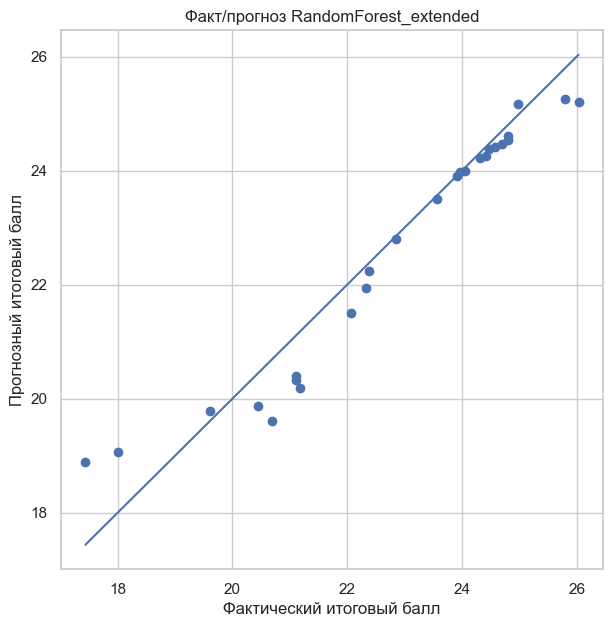

In [233]:
#График факт/прогноз Random Forest

plt.figure(figsize=(7, 7))
plt.scatter(
    test_predictions["actual_total_score"],
    test_predictions["pred_rf_extended"]
)

plt.plot(
    [test_predictions["actual_total_score"].min(), test_predictions["actual_total_score"].max()],
    [test_predictions["actual_total_score"].min(), test_predictions["actual_total_score"].max()],
)

plt.title("Факт/прогноз RandomForest_extended")
plt.xlabel("Фактический итоговый балл")
plt.ylabel("Прогнозный итоговый балл")
plt.show()

Для модели RandomForest_extended точки расположены заметно ближе к диагонали, чем у линейной регрессии. Это подтверждает более высокую точность модели и согласуется с результатами сравнения по метрикам качества.

In [234]:
#Таблица абсолютных ошибок

error_comparison = test_predictions[
    [
        "MO_code",
        "actual_total_score",
        "abs_error_lr_basic",
        "abs_error_rf_extended",
    ]
].copy()

error_comparison.head(10)

,MO_code,actual_total_score,abs_error_lr_basic,abs_error_rf_extended
0,MO_01,23.965,0.868561,0.010991
1,MO_02,20.440,0.760424,0.561352
2,MO_03,19.615,0.101130,0.175437
3,MO_04,24.475,1.508899,0.090179
4,MO_05,22.375,0.054316,0.127424
5,MO_06,24.315,0.928184,0.091345
6,MO_07,24.985,1.561442,0.184900
7,MO_08,21.110,0.334952,0.708595
8,MO_09,23.560,0.108998,0.055468
9,MO_10,17.440,1.341389,1.450354


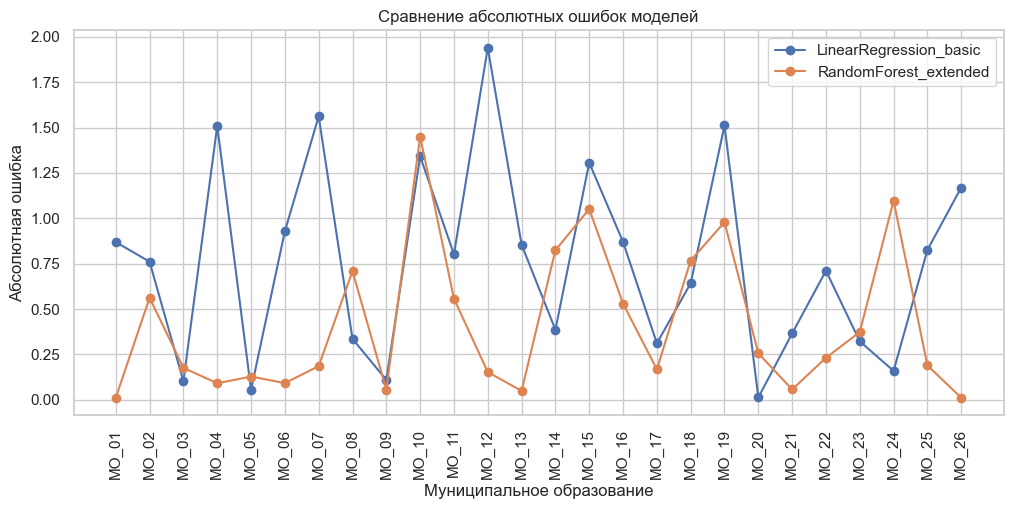

In [235]:
#График сравнения абсолютных ошибок

plt.figure(figsize=(12, 5))

plt.plot(
    test_predictions["MO_code"],
    test_predictions["abs_error_lr_basic"],
    marker="o",
    label="LinearRegression_basic"
)

plt.plot(
    test_predictions["MO_code"],
    test_predictions["abs_error_rf_extended"],
    marker="o",
    label="RandomForest_extended"
)

plt.title("Сравнение абсолютных ошибок моделей")
plt.xlabel("Муниципальное образование")
plt.ylabel("Абсолютная ошибка")
plt.xticks(rotation=90)
plt.legend()
plt.show()

График абсолютных ошибок показывает, что RandomForest_extended в большинстве наблюдений демонстрирует меньшую ошибку по сравнению с LinearRegression_basic. Это подтверждает, что выигрыш Random Forest по интегральным метрикам не является случайным и проявляется на уровне отдельных объектов тестовой выборки.

In [236]:
#Поиск наблюдений с максимальной ошибкой

# Находим наблюдения с наибольшими ошибками
largest_errors = test_predictions.sort_values(
    "abs_error_rf_extended",
    ascending=False
).head(5)

largest_errors

,MO_code,quarter,actual_total_score,pred_lr_basic,pred_rf_extended,error_lr_basic,error_rf_extended,abs_error_lr_basic,abs_error_rf_extended
9,MO_10,Q3_2024,17.440,16.098611,18.890354,1.341389,-1.450354,1.341389,1.450354
23,MO_24,Q3_2024,20.700,20.541395,19.603601,0.158605,1.096399,0.158605,1.096399
14,MO_15,Q3_2024,18.010,16.704043,19.060766,1.305957,-1.050766,1.305957,1.050766
18,MO_19,Q3_2024,21.175,19.663751,20.196689,1.511249,0.978311,1.511249,0.978311
13,MO_14,Q3_2024,26.035,25.649393,25.210893,0.385607,0.824107,0.385607,0.824107


Анализ наблюдений с наибольшими ошибками позволяет выявить муниципальные образования, для которых прогнозирование оказывается наиболее сложным. Такие случаи могут быть связаны с нестабильной динамикой показателей, особенностями структуры сферовых баллов или ограниченным объемом исторических данных. Эти наблюдения представляют интерес для дальнейшего анализа и доработки модели.

In [237]:
test_predictions.to_csv("predictions_test.csv", index=False)

print("Сохранен файл predictions_test.csv")

Сохранен файл predictions_test.csv


Анализ фактических и прогнозных значений показал, что обе рассматриваемые модели обеспечивают приемлемое качество на тестовой выборке, однако RandomForest_extended демонстрирует более точное совпадение с фактическими значениями и более низкие абсолютные ошибки. При этом LinearRegression_basic остается важной интерпретируемой моделью, которую можно использовать как explainable baseline в рамках MVP.

In [249]:
import joblib

# Сохраняем обученные модели
joblib.dump(linear_regression_basic, "model_linear_regression_basic.pkl")
joblib.dump(random_forest_extended, "model_random_forest_extended.pkl")

print("Сохранены модели:")
print("- model_linear_regression_basic.pkl")
print("- model_random_forest_extended.pkl")

Сохранены модели:
- model_linear_regression_basic.pkl
- model_random_forest_extended.pkl


In [250]:
# Сохраняем итоговый датасет с новыми признаками
dataset_features.to_excel("dataset_features_ready.xlsx", index=False)

print("Сохранен файл dataset_features_ready.xlsx")

Сохранен файл dataset_features_ready.xlsx


In [240]:
# Сортируем модели по MAPE (или MAE)
model_metrics_sorted = model_metrics.sort_values(by="MAPE")

print("Сравнение моделей:")
print(model_metrics_sorted)

# Выбор лучшей модели
best_model = model_metrics_sorted.iloc[0]

print("\nЛучшая модель:")
print(best_model)

Сравнение моделей:
                    model    MAE   RMSE   MAPE
2   RandomForest_extended  0.413  0.572   1.96
1  LinearRegression_basic  0.760  0.924   3.38
0           Baseline_mean  2.691  3.104  11.46

Лучшая модель:
model    RandomForest_extended
MAE                      0.413
RMSE                     0.572
MAPE                      1.96
Name: 2, dtype: object
